In [1]:
print("Hello")

Hello


🐍 Python for Network Engineers — Day 1: f-strings (formatted strings)
Part 1 — The concept & why it matters
An f-string is a string prefixed with f that lets you drop variables and expressions directly inside { } placeholders. Instead of clumsy concatenation with +, you write the value right where it belongs.
For a network engineer this is everyday gold: you build CLI commands, format log lines, label interfaces, and render IP/hostname output constantly. f-strings make that clean and readable — and you can even pad/align numbers (great for tidy tabular output of ports, VLANs, or interface counters).
Part 2 — Example code
hostname = "core-sw-01"
mgmt_ip = "10.0.0.5"
vlan = 20
# Build a config command on the fly
command = f"interface vlan {vlan}"
print(command)              # interface vlan 20
# Format a clean status line
print(f"{hostname} ({mgmt_ip}) -> VLAN {vlan} is UP")
# core-sw-01 (10.0.0.5) -> VLAN 20 is UP
# Alignment for tidy tables (<15 = left-pad to 15 chars)
interfaces = {"Gi0/1": "up", "Gi0/2": "down", "Te1/1": "up"}
for intf, state in interfaces.items():
    print(f"{intf:<10}{state:>6}")
# Gi0/1         up
# Gi0/2       down
# Te1/1         up
Part 3 — Practice question
You're given:
device = "edge-rtr-02"
interface = "Gi0/3"
speed_mbps = 1000
Write a single f-string that prints:
edge-rtr-02 | Gi0/3 | 1.0 Gbps
👉 Hint: convert Mbps to Gbps inside the placeholder (speed_mbps / 1000) and format it to one decimal place using {value:.1f}.
Reply with your answer here whenever you like — tomorrow we'll build on this! 🚀

In [3]:
hostname = "core-sw-01"
mgmpt_ip = "10.0.0.5"
vlan = 20

# Build a config command on the fly
command = f"interface vlan {vlan}"
print(command)

# Format a clean status line
print(f"{hostname} ({mgmpt_ip})")
# core-sw-01 (10.0.0.5) -> VLAN 20 is UP




interface vlan 20
core-sw-01 (10.0.0.5)


In [4]:
# Alignment for tidy tables (<15 = left-pad to 15 chars)
interfaces = {"Gi0/1": "up", "Gi0/2":"down", "Te1/1": "up"}
for intf, state in interfaces.items():
    print(f"{intf:<10}{state:>6}")

Gi0/1         up
Gi0/2       down
Te1/1         up


In [5]:
print(f"{'Interface':<10}{'Status':>6}")
print("-" * 16)
for intf, state in interfaces.items():
    print(f"{intf:<10}{state:>6}")

Interface Status
----------------
Gi0/1         up
Gi0/2       down
Te1/1         up


Let’s break your code **step by step** in a clean, practical way 👇

***

## ✅ 1. Your Code

```python
interfaces = {"Gi0/1": "up", "Gi0/2":"down", "Te1/1": "up"}

for intf, state in interfaces.items():
    print(f"{intf:<10}{state:>6}")
```

***

## ✅ 2. What the dictionary is

```python
interfaces = {"Gi0/1": "up", "Gi0/2":"down", "Te1/1": "up"}
```

* This is a dictionary
* Key = interface name
* Value = status

👉 Example:

* `"Gi0/1"` → `"up"`
* `"Gi0/2"` → `"down"`

***

## ✅ 3. Loop explanation

```python
for intf, state in interfaces.items():
```

* `.items()` gives **key + value pairs**
* Each iteration:
  * `intf` = key (interface name)
  * `state` = value (status)

👉 Iteration looks like:

* `("Gi0/1", "up")`
* `("Gi0/2", "down")`
* `("Te1/1", "up")`

***

## ✅ 4. Important part — f-string formatting

```python
print(f"{intf:<10}{state:>6}")
```

This is where your formatting magic happens.

### 🔹 Rule:

In f-strings:

```
{value:alignment width}
```

* `<` → left align
* `>` → right align
* Number → total width (including spaces) [\[geeksforgeeks.org\]](https://www.geeksforgeeks.org/python/string-alignment-in-python-f-string/)

***

## ✅ 5. `{intf:<10}` → LEFT ALIGN

* Reserve **10 characters**
* Put `intf` on the **left**
* Add spaces on the **right**

Example:

```
"Gi0/1" → "Gi0/1     "
```

👉 Because `"Gi0/1"` is 5 chars → 5 spaces added

***

## ✅ 6. `{state:>6}` → RIGHT ALIGN

* Reserve **6 characters**
* Put `state` on the **right**
* Add spaces on the **left**

Example:

```
"up" → "    up"
"down" → "  down"
```

***

## ✅ 7. Final Output

```
Gi0/1         up
Gi0/2       down
Te1/1         up
```

➡️ Everything is nicely aligned like a table  
➡️ This is very useful for:

* Network CLI outputs
* Logging
* Reports

***

## ✅ 8. Why this is important (networking context 🔥)

Since you work with network devices, this helps you:

* Print interface tables cleanly
* Format script outputs (like LACP, BGP summaries)
* Create CLI-style outputs

Example upgrade:

```python
print(f"{'Interface':<10}{'Status':>6}")
print("-" * 16)
for intf, state in interfaces.items():
    print(f"{intf:<10}{state:>6}")
```

***

## ✅ 9. Short summary

* `{intf:<10}` → left align, width 10
* `{state:>6}` → right align, width 6
* Used for **clean column formatting**

***

If you want, I can extend this into a **real network-style table (with VLAN, speed, errors)** — useful for your automation scripts.


In [6]:
interfaces = {
    "Gi0/1": {"status": "up", "speed": "1G", "errors": 0},
    "Gi0/2": {"status": "down", "speed": "1G", "errors": 5},
    "Te1/1": {"status": "up", "speed": "10G", "errors": 0}
}

print(f"{'Interface':<10}{'Status':<8}{'Speed':<8}{'Errors':>6}")
print("-" * 32)

for intf, data in interfaces.items():
    print(f"{intf:<10}{data['status']:<8}{data['speed']:<8}{data['errors']:>6}")

Interface Status  Speed   Errors
--------------------------------
Gi0/1     up      1G           0
Gi0/2     down    1G           5
Te1/1     up      10G          0


In [7]:
lags = {
    "Po1": {"members": 2, "state": "up", "protocol": "LACP"},
    "Po10": {"members": 4, "state": "down", "protocol": "LACP"},
    "Po20": {"members": 1, "state": "up", "protocol": "Static"}
}

print(f"{'LAG':<8}{'Members':<10}{'State':<8}{'Protocol':>10}")
print("-" * 36)

for lag, data in lags.items():
    print(f"{lag:<8}{data['members']:<10}{data['state']:<8}{data['protocol']:>10}")


LAG     Members   State     Protocol
------------------------------------
Po1     2         up            LACP
Po10    4         down          LACP
Po20    1         up          Static


In [8]:
vlans = {
    10: {"name": "Users", "status": "active"},
    20: {"name": "Servers", "status": "active"},
    30: {"name": "Guest", "status": "suspended"}
}

print(f"{'VLAN':<6}{'Name':<12}{'Status':>10}")
print("-" * 28)

for vlan, data in vlans.items():
    print(f"{vlan:<6}{data['name']:<12}{data['status']:>10}")

VLAN  Name            Status
----------------------------
10    Users           active
20    Servers         active
30    Guest        suspended


In [9]:
bgp_neighbors = {
    "10.0.0.1": {"asn": 65001, "state": "Established", "prefixes": 120},
    "10.0.0.2": {"asn": 65002, "state": "Idle", "prefixes": 0},
    "10.0.0.3": {"asn": 65003, "state": "Established", "prefixes": 98}
}

print(f"{'Neighbor':<15}{'ASN':<8}{'State':<15}{'Prefixes':>10}")
print("-" * 48)

for nbr, data in bgp_neighbors.items():
    print(f"{nbr:<15}{data['asn']:<8}{data['state']:<15}{data['prefixes']:>10}")

Neighbor       ASN     State            Prefixes
------------------------------------------------
10.0.0.1       65001   Established           120
10.0.0.2       65002   Idle                    0
10.0.0.3       65003   Established            98


In [12]:
print(f"{'Device':^20}{'Status':^10}")
print("-" * 30)

devices = {
    "ear02.str07": "UP",
    "owa01.str40": "DOWN"
}

for dev, status in devices.items():
    print(f"{dev:^20}{status:^10}")

       Device         Status  
------------------------------
    ear02.str07         UP    
    owa01.str40        DOWN   


In [11]:
devices = ["ear02.str07", "owa01", "core-router-1"]

max_len = max(len(d) for d in devices)

for d in devices:
    print(f"{d:<{max_len}}  ONLINE")


ear02.str07    ONLINE
owa01          ONLINE
core-router-1  ONLINE


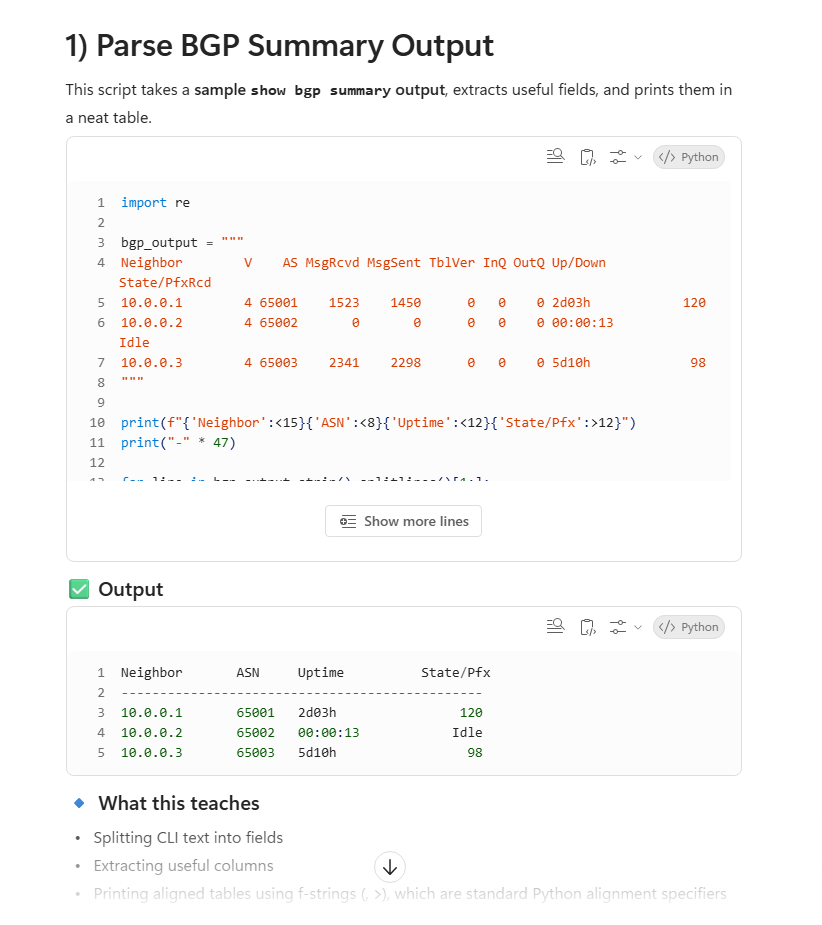

In [13]:
import re

bgp_output = """
Neighbor        V    AS MsgRcvd MsgSent TblVer InQ OutQ Up/Down  State/PfxRcd
10.0.0.1        4 65001    1523    1450      0   0    0 2d03h            120
10.0.0.2        4 65002       0       0      0   0    0 00:00:13         Idle
10.0.0.3        4 65003    2341    2298      0   0    0 5d10h             98
"""

print(f"{'Neighbor':<15}{'ASN':<8}{'Uptime':<12}{'State/Pfx':>12}")
print("-" * 47)

for line in bgp_output.strip().splitlines()[1:]:
    parts = line.split()
    neighbor = parts[0]
    asn = parts[2]
    uptime = parts[8]
    state_pfx = parts[9]
    print(f"{neighbor:<15}{asn:<8}{uptime:<12}{state_pfx:>12}")

Neighbor       ASN     Uptime         State/Pfx
-----------------------------------------------
10.0.0.1       65001   2d03h                120
10.0.0.2       65002   00:00:13            Idle
10.0.0.3       65003   5d10h                 98


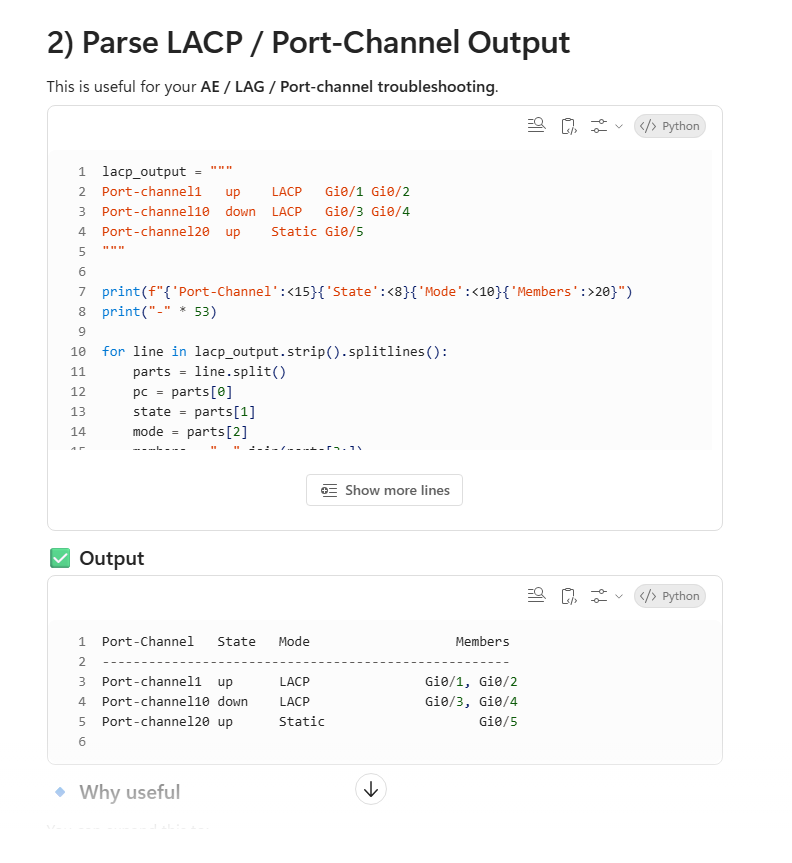

In [14]:
lacp_output = """
Port-channel1   up    LACP   Gi0/1 Gi0/2
Port-channel10  down  LACP   Gi0/3 Gi0/4
Port-channel20  up    Static Gi0/5
"""

print(f"{'Port-Channel':<15}{'State':<8}{'Mode':<10}{'Members':>20}")
print("-" * 53)

for line in lacp_output.strip().splitlines():
    parts = line.split()
    pc = parts[0]
    state = parts[1]
    mode = parts[2]
    members = ", ".join(parts[3:])
    print(f"{pc:<15}{state:<8}{mode:<10}{members:>20}")

Port-Channel   State   Mode                   Members
-----------------------------------------------------
Port-channel1  up      LACP              Gi0/1, Gi0/2
Port-channel10 down    LACP              Gi0/3, Gi0/4
Port-channel20 up      Static                   Gi0/5


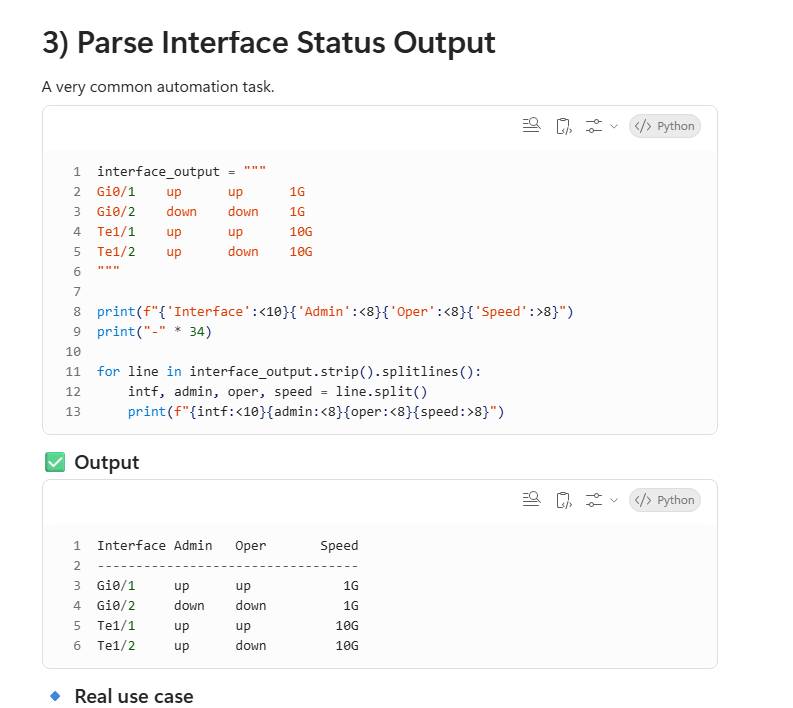

In [15]:
interface_output = """
Gi0/1    up      up      1G
Gi0/2    down    down    1G
Te1/1    up      up      10G
Te1/2    up      down    10G
"""

print(f"{'Interface':<10}{'Admin':<8}{'Oper':<8}{'Speed':>8}")
print("-" * 34)

for line in interface_output.strip().splitlines():
    intf, admin, oper, speed = line.split()
    print(f"{intf:<10}{admin:<8}{oper:<8}{speed:>8}")

Interface Admin   Oper       Speed
----------------------------------
Gi0/1     up      up            1G
Gi0/2     down    down          1G
Te1/1     up      up           10G
Te1/2     up      down         10G


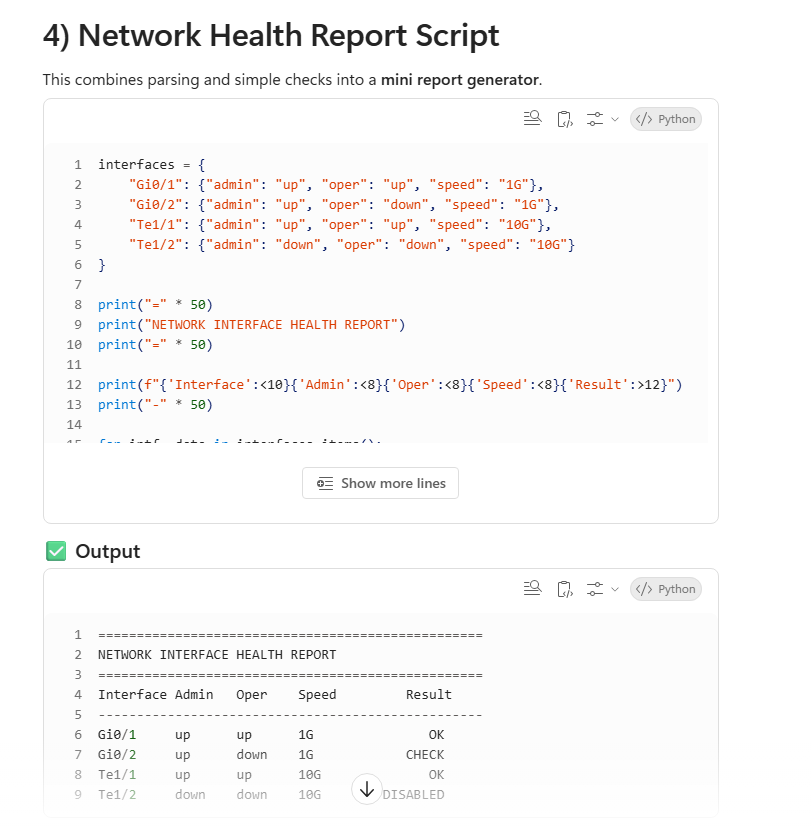

In [16]:
interfaces = {
    "Gi0/1": {"admin": "up", "oper": "up", "speed": "1G"},
    "Gi0/2": {"admin": "up", "oper": "down", "speed": "1G"},
    "Te1/1": {"admin": "up", "oper": "up", "speed": "10G"},
    "Te1/2": {"admin": "down", "oper": "down", "speed": "10G"}
}

print("=" * 50)
print("NETWORK INTERFACE HEALTH REPORT")
print("=" * 50)

print(f"{'Interface':<10}{'Admin':<8}{'Oper':<8}{'Speed':<8}{'Result':>12}")
print("-" * 50)

for intf, data in interfaces.items():
    admin = data["admin"]
    oper = data["oper"]
    speed = data["speed"]

    if admin == "up" and oper == "up":
        result = "OK"
    elif admin == "up" and oper == "down":
        result = "CHECK"
    else:
        result = "DISABLED"

    print(f"{intf:<10}{admin:<8}{oper:<8}{speed:<8}{result:>12}")


NETWORK INTERFACE HEALTH REPORT
Interface Admin   Oper    Speed         Result
--------------------------------------------------
Gi0/1     up      up      1G                OK
Gi0/2     up      down    1G             CHECK
Te1/1     up      up      10G               OK
Te1/2     down    down    10G         DISABLED


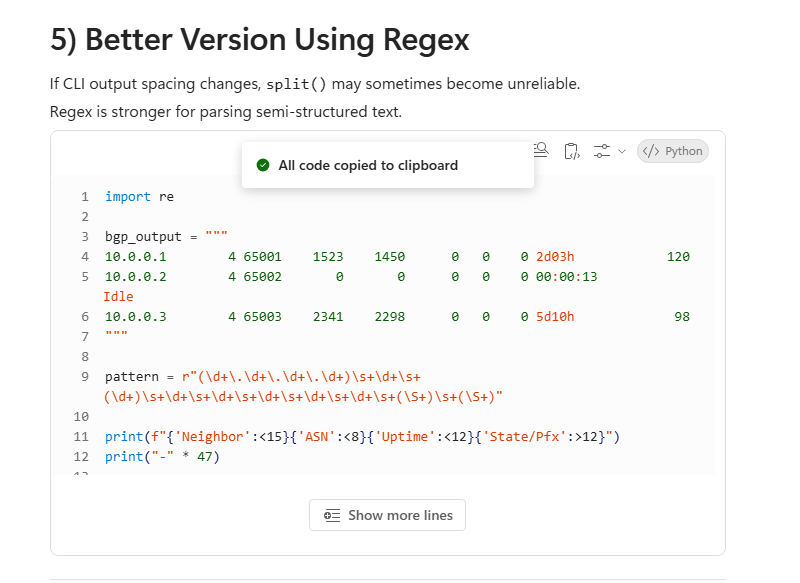

In [17]:
import re

bgp_output = """
10.0.0.1        4 65001    1523    1450      0   0    0 2d03h            120
10.0.0.2        4 65002       0       0      0   0    0 00:00:13         Idle
10.0.0.3        4 65003    2341    2298      0   0    0 5d10h             98
"""

pattern = r"(\d+\.\d+\.\d+\.\d+)\s+\d+\s+(\d+)\s+\d+\s+\d+\s+\d+\s+\d+\s+\d+\s+(\S+)\s+(\S+)"

print(f"{'Neighbor':<15}{'ASN':<8}{'Uptime':<12}{'State/Pfx':>12}")
print("-" * 47)

for match in re.finditer(pattern, bgp_output):
    neighbor = match.group(1)
    asn = match.group(2)
    uptime = match.group(3)
    state_pfx = match.group(4)
    print(f"{neighbor:<15}{asn:<8}{uptime:<12}{state_pfx:>12}")

Neighbor       ASN     Uptime         State/Pfx
-----------------------------------------------
10.0.0.1       65001   2d03h                120
10.0.0.2       65002   00:00:13            Idle
10.0.0.3       65003   5d10h                 98


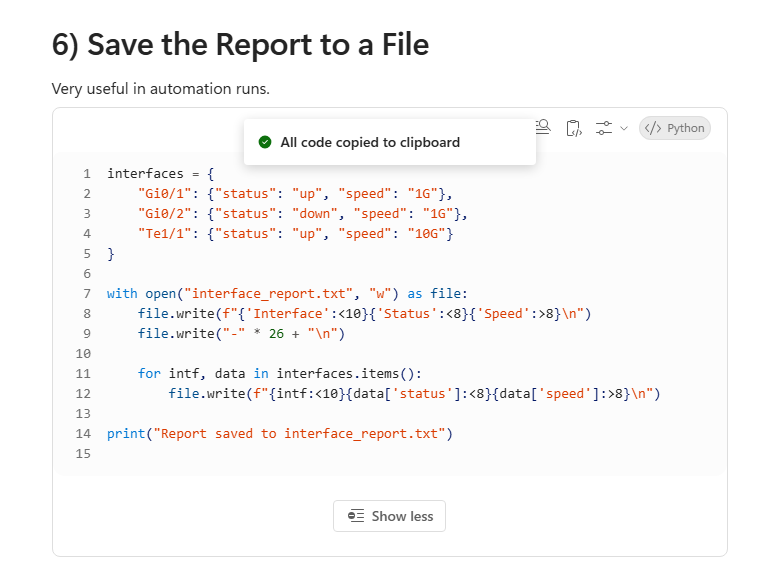

In [18]:
interfaces = {
    "Gi0/1": {"status": "up", "speed": "1G"},
    "Gi0/2": {"status": "down", "speed": "1G"},
    "Te1/1": {"status": "up", "speed": "10G"}
}

with open("interface_report.txt", "w") as file:
    file.write(f"{'Interface':<10}{'Status':<8}{'Speed':>8}\n")
    file.write("-" * 26 + "\n")

    for intf, data in interfaces.items():
        file.write(f"{intf:<10}{data['status']:<8}{data['speed']:>8}\n")

print("Report saved to interface_report.txt")


Report saved to interface_report.txt


In [19]:
interfaces = {
    "Gi0/1": {"admin": "up", "oper": "up", "speed": "1G"},
    "Gi0/2": {"admin": "up", "oper": "down", "speed": "1G"},
    "Te1/1": {"admin": "up", "oper": "up", "speed": "10G"},
    "Te1/2": {"admin": "down", "oper": "down", "speed": "10G"}
}

print(f"{'Interface':<10}{'Admin':<8}{'Oper':<8}{'Speed':<8}{'Remark':>10}")
print("-" * 44)

for intf, data in interfaces.items():
    if data["admin"] == "up" and data["oper"] == "down":
        remark = "ALERT"
    elif data["admin"] == "up" and data["oper"] == "up":
        remark = "OK"
    else:
        remark = "OFF"

    print(f"{intf:<10}{data['admin']:<8}{data['oper']:<8}{data['speed']:<8}{remark:>10}")

Interface Admin   Oper    Speed       Remark
--------------------------------------------
Gi0/1     up      up      1G              OK
Gi0/2     up      down    1G           ALERT
Te1/1     up      up      10G             OK
Te1/2     down    down    10G            OFF


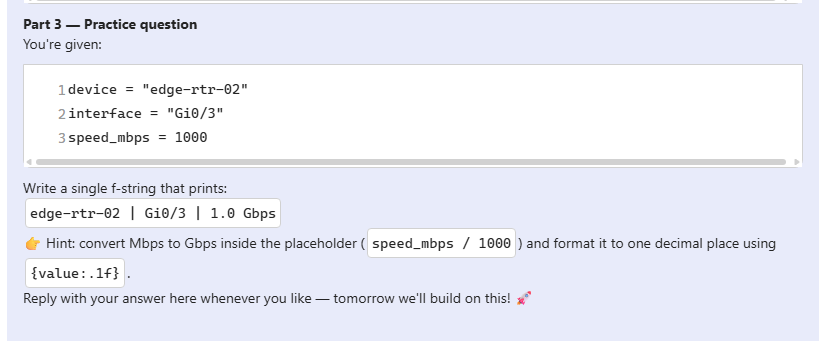

In [23]:
device = "edge-rtr-02"
interface = "Gi0/3"
speed_mbps = 1000

print(f"{device} | {interface} | {speed_mbps / 1000:.1f} Gbps")

edge-rtr-02 | Gi0/3 | 1.0 Gbps


🐍 Python for Network Engineers — Day 2: Lists & for loops


Part 1 — The concept & why it matters


A list is an ordered, changeable collection of items written in square brackets: ["sw1", "sw2", "sw3"]. A for loop lets you walk through that collection one item at a time and do the same work on each.


Why this matters for network engineering: almost everything you automate is "do X to every device / interface / VLAN / IP." Instead of copy-pasting a command 50 times, you store the 50 devices in a list and loop once. This is the foundation of every config-push, audit, and health-check script you'll ever write.


Handy basics:


devices[0] → first item (Python counts from 0)
devices.append("sw4") → add an item
len(devices) → how many items
for d in devices: → loop over each one
Part 2 — Example code
# A list of switches we manage
devices = ["core-sw1", "core-sw2", "access-sw1", "access-sw2"]
# Loop over each device and build a command
for device in devices:
    print(f"Connecting to {device}...")
    print(f"  Running: show version on {device}")
# Add a newly racked switch
devices.append("access-sw3")
print(f"\nWe now manage {len(devices)} devices.")
# enumerate() gives you a counter + the item — great for numbered output
for index, device in enumerate(devices, start=1):
    print(f"{index}. {device}")

Sample output:
Connecting to core-sw1...
  Running: show version on core-sw1
Connecting to core-sw2...
  Running: show version on core-sw2
... (and so on)
We now manage 5 devices.
1. core-sw1
2. core-sw2
3. access-sw1
4. access-sw2
5. access-sw3

Part 3 — Practice question 📝
You have this list of management IPs:
mgmt_ips = ["10.0.0.1", "10.0.0.2", "10.0.0.3"]

Write a for loop that prints, for each IP, the line: Pinging 10.0.0.1 (using an f-string from Day 1!). Bonus: after the loop, append "10.0.0.4" to the list and print how many IPs are now in it.
Reply with your answer and I'll check it. Happy coding! 🚀
— Microsoft Internal Python Notes

In [24]:
# A list of switches we manage
devices = ["core-sw1", "core-sw2", "access-sw1", "access-sw2"]

# Loop over each device and build a command
for device in devices:
    print(f"Connecting to {device} .......")
    print(f"Running: Show version on {device}")

Connecting to core-sw1 .......
Running: Show version on core-sw1
Connecting to core-sw2 .......
Running: Show version on core-sw2
Connecting to access-sw1 .......
Running: Show version on access-sw1
Connecting to access-sw2 .......
Running: Show version on access-sw2


In [26]:
#add a newly racked switch. 
devices.append("access-sw3")
print(devices)
print(f"\n We now manage {len(devices)} devices. ")

['core-sw1', 'core-sw2', 'access-sw1', 'access-sw2', 'access-sw3', 'access-sw3']

 We now manage 6 devices. 


In [28]:
#enumerate () gives you a counter + the item - great for numbered output. 

for index, device in enumerate(devices, start=1):
    print(f"{index}. {device}")

1. core-sw1
2. core-sw2
3. access-sw1
4. access-sw2
5. access-sw3
6. access-sw3
7. access-sw3


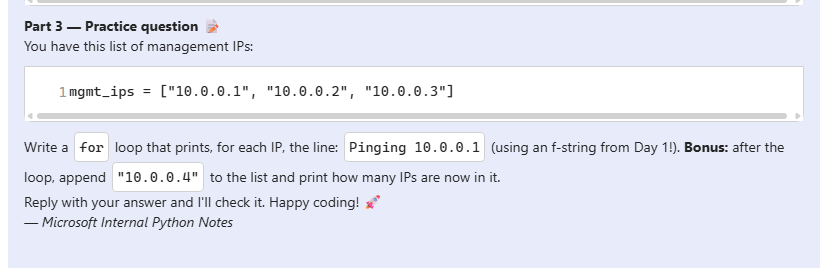

In [29]:
mgmt_ips = ["10.0.0.1", "10.0.0.2", "10.0.0.3"]

for mgmt in mgmt_ips:
    print(mgmt)

10.0.0.1
10.0.0.2
10.0.0.3


In [30]:
mgmt_ips.append("10.0.0.4")
print(mgmt_ips)
print(f"\n we now see all the {len(mgmt_ips)} mgmpt_ip address")

['10.0.0.1', '10.0.0.2', '10.0.0.3', '10.0.0.4']

 we now see all the 4 mgmpt_ip address


🐍 Python for Network Engineers — Day 3: Dictionaries
Part 1 — The concept & why it matters
A dictionary is a collection of key → value pairs, written in curly braces: {"sw1": "10.0.0.1"}. Unlike a list (which you access by position), you access a dictionary by its key — a meaningful name you choose.
This is the data structure for network work, because so much of our world is a mapping: hostname → IP, interface → status, VLAN ID → name, device → vendor. Instead of remembering "the IP is at index 3," you just ask for it by name: devices["sw1"]. Dictionaries are fast to look up, easy to read, and they're exactly the shape of JSON returned by network APIs (RESTCONF, Meraki, NetBox, etc.).
Part 2 — Example code snippets
Creating and reading a dictionary (device → IP):
devices = {
    "sw1": "10.0.0.1",
    "sw2": "10.0.0.2",
    "rtr1": "10.0.0.254",
}
print(devices["sw1"])        # 10.0.0.1
print(len(devices))          # 3  (number of devices)

Adding, updating, and safely reading with .get():
devices["fw1"] = "10.0.0.10"     # add a new entry
devices["sw1"] = "10.0.0.5"      # update an existing one
# .get() avoids a crash if the key is missing — returns a default instead
print(devices.get("sw9", "NOT FOUND"))   # NOT FOUND

Looping over a dictionary — the everyday pattern:
for hostname, ip in devices.items():
    print(f"{hostname} -> {ip}")
# sw1 -> 10.0.0.5
# sw2 -> 10.0.0.2
# rtr1 -> 10.0.0.254
# fw1 -> 10.0.0.10

Nested dictionary — richer data per device:
inventory = {
    "sw1": {"ip": "10.0.0.1", "vendor": "Arista", "model": "7050"},
    "rtr1": {"ip": "10.0.0.254", "vendor": "Cisco", "model": "ISR4451"},
}
print(inventory["rtr1"]["vendor"])   # Cisco

Part 3 — Practice question
You're given this dictionary of interfaces and their status:
interfaces = {
    "Gi0/1": "up",
    "Gi0/2": "down",
    "Gi0/3": "up",
    "Gi0/4": "down",
}

👉 Write a loop that prints only the interface names that are "down". Bonus: count how many are down and print the total.
(Hint: loop with .items() and use an if to check the status.)
Happy coding! 🚀
— Microsoft Internal Python Notes

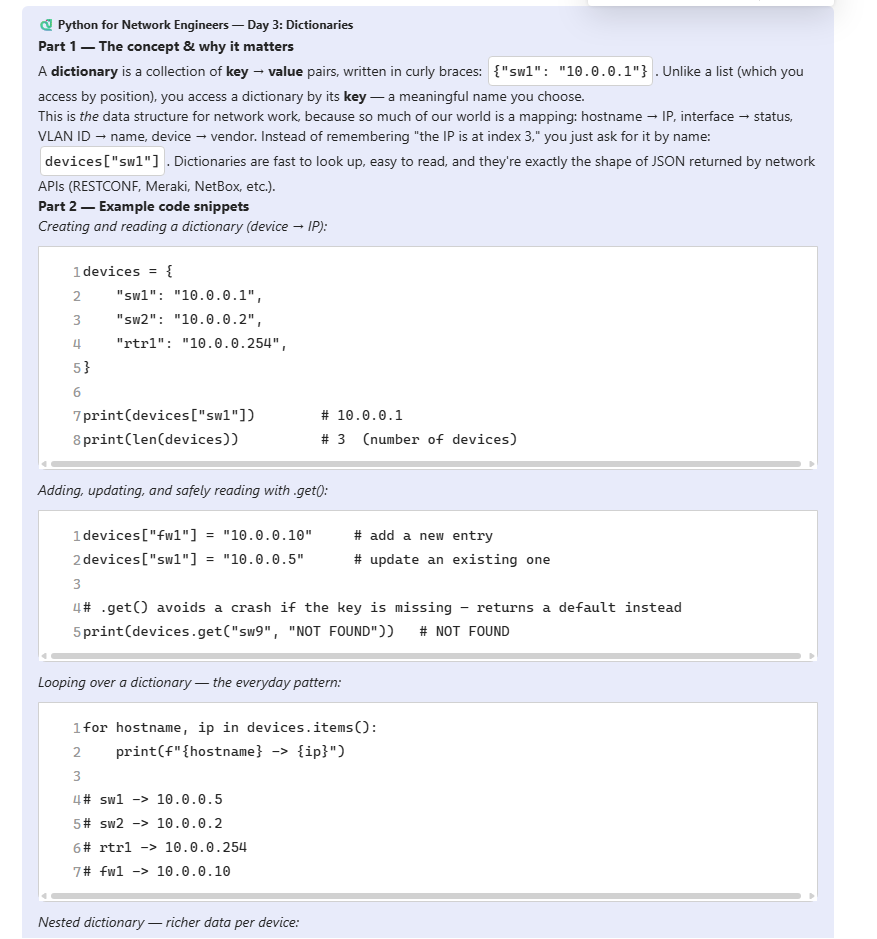

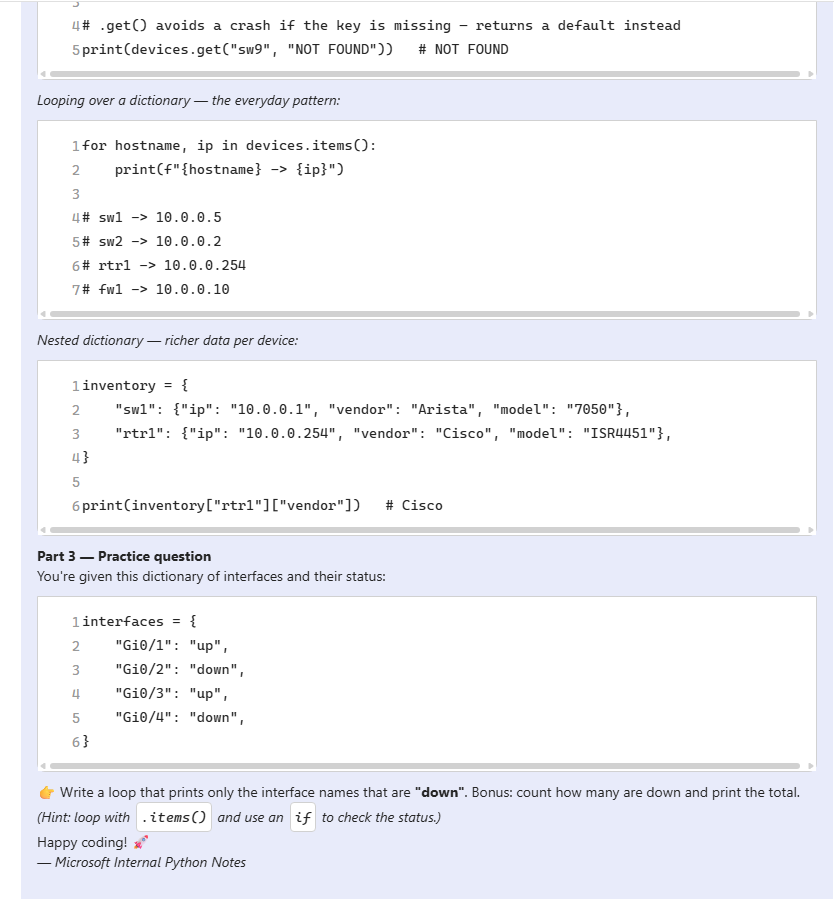

In [31]:
devices = {
    "sw1" : "10.0.0.1",
    "sw2" : "10.0.0.2",
    "rtr1" : "10.0.0.254"
}

print(devices["sw1"])
print(len(devices))

10.0.0.1
3


In [35]:
print(devices["sw2"])
print(devices["sw3"])

10.0.0.2


KeyError: 'sw3'

In [33]:
print("sw2")

sw2


In [36]:
print(devices["sw2"])
print(devices["rtr1"])

10.0.0.2
10.0.0.254


Adding, updating, and safely reading with .get():

In [38]:
devices["fw1"] = "10.0.0.10"      # add a new entry
devices["sw1"] = "10.0.0.5"          # update an existing one


# .get() avoids a crash if the key is missing — returns a default instead
print(devices.get("sw9", "NOT FOUND"))      #if the item is not found in dictionary then it will print not found. 
 


NOT FOUND


Looping over a dictionary — the everyday pattern:

In [39]:
for hostname, ip in devices.items():
    print(f"{hostname} --> {ip}")

sw1 --> 10.0.0.5
sw2 --> 10.0.0.2
rtr1 --> 10.0.0.254
fw1 --> 10.0.0.10


Nested dictionary — richer data per device:

In [40]:
inventory= {
    "sw1": {"ip": "10.0.0.1", "vendor":"Arista", "model":"7050"},
    "rtr1":{"ip":"10.0.0.254", "vendor":"Cisco", "model":"ISR4451"},
    
    }

print(inventory["rtr1"]["vendor"])

Cisco


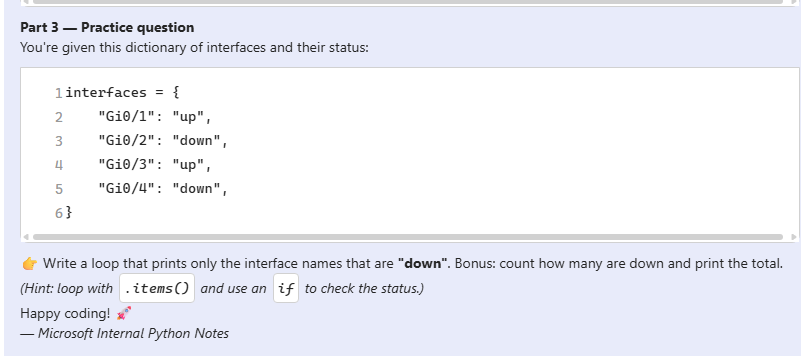

In [41]:
interfaces = {
    "Gi0/1": "up",
    "Gi0/2": "down",
    "Gi0/3": "up",
    "Gi0/4": "down",
}